In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lswt import *
from bz import *
from mesh import *
from vectutil import*

# get lmodern font from LaTeX
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{lmodern}"
})

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[(0.2298057, 0.298717966, 0.753683153, 0.8)])

In [2]:
hamil, lat, base = InputProcessing.initialize_from_txtfile('kagome.txt')

In [5]:
lat.sublats[0].num_unitvects

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [3]:
hamil.lat.vects

Matrix([
[2*a,         0, 0],
[  a, sqrt(3)*a, 0],
[  0,         0, 1]])

In [4]:
hamil.lat.num_vects

array([[2.        , 0.        , 0.        ],
       [1.        , 1.73205081, 0.        ],
       [0.        , 0.        , 1.        ]])

In [5]:
hamil.lat.rcpr_vects

Matrix([
[pi/a,  -sqrt(3)*pi/(3*a),    0],
[   0, 2*sqrt(3)*pi/(3*a),    0],
[   0,                  0, 2*pi]])

In [6]:
hamil.lat.num_rcpr_vects

array([[ 3.14159265, -1.81379936,  0.        ],
       [ 0.        ,  3.62759873,  0.        ],
       [ 0.        ,  0.        ,  6.28318531]])

In [7]:
# hamil.assume_real_params()

In [8]:
hamil.holstein_primakoff(simplify=True)

Matrix([
[                                                                                                                                                                                                      -2*A*S1 - B_z*g - 4*J*S1,                                                                                                                   (-I*Dz*exp(1.0*I*a*(k_x + sqrt(3)*k_y)) - I*Dz + J*exp(1.0*I*a*(k_x + sqrt(3)*k_y)) + J)*sqrt(S1**2)*exp(-0.5*I*a*(k_x + sqrt(3)*k_y)),                                                        (I*Dz*exp(2*I*a*k_x) + I*Dz + J*exp(2*I*a*k_x) + J)*sqrt(S1**2)*exp(-1.0*I*a*k_x),                                                                                                                                         0,                                                                                                                                                                                                                                 0,             

In [9]:
hamil.parameterize_hamil(1e-8)

1e-08

In [10]:
hamil.num_bilinear_hamil(0.5,0.5,0.5)

array([[ 4.00000001+0.00000000e+00j, -1.55134965+1.11022302e-16j,
        -1.75516512+0.00000000e+00j,  0.        +0.00000000e+00j,
         0.        +0.00000000e+00j,  0.        +0.00000000e+00j],
       [-1.55134965-1.11022302e-16j,  4.00000001+0.00000000e+00j,
        -1.96659973+1.11022302e-16j,  0.        +0.00000000e+00j,
         0.        +0.00000000e+00j,  0.        +0.00000000e+00j],
       [-1.75516512+0.00000000e+00j, -1.96659973-1.11022302e-16j,
         4.00000001+0.00000000e+00j,  0.        +0.00000000e+00j,
         0.        +0.00000000e+00j,  0.        +0.00000000e+00j],
       [ 0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
         0.        +0.00000000e+00j,  4.00000001+0.00000000e+00j,
        -1.55134965+1.11022302e-16j, -1.75516512+0.00000000e+00j],
       [ 0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
         0.        +0.00000000e+00j, -1.55134965-1.11022302e-16j,
         4.00000001+0.00000000e+00j, -1.96659973+1.11022302e-16j],
     

In [11]:
hamil.bog_trafo(0,0,0)

(array([ 6.00000001e+00,  6.00000001e+00,  9.99999867e-09, -6.00000001e+00,
        -6.00000001e+00, -9.99999867e-09]),
 array([[ 0.8099091 +0.j, -0.10350804+0.j,  0.57735024+0.j,
          0.        -0.j,  0.        -0.j,  0.        -0.j],
        [-0.31531396+0.j,  0.75315588+0.j,  0.57735024+0.j,
          0.        -0.j,  0.        -0.j,  0.        -0.j],
        [-0.49459514+0.j, -0.64964784+0.j,  0.57735024+0.j,
          0.        -0.j,  0.        -0.j,  0.        -0.j],
        [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
          0.8099091 -0.j, -0.10350804-0.j,  0.57735024-0.j],
        [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
         -0.31531396-0.j,  0.75315588-0.j,  0.57735024-0.j],
        [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
         -0.49459514-0.j, -0.64964784-0.j,  0.57735024-0.j]]))

In [12]:
angle_between(hamil.lat.num_rcpr_vects[0], hamil.lat.num_rcpr_vects[1])

np.float64(2.0943951023931957)

In [13]:
OneDimDispersion.get_pathcoords(['G', r'$\Gamma$', np.array((0, 0, 0))], ['M', r'M', np.array((1/2, 0, 0))], ['K', r'K', np.array((1/3, -1/3, 0))], ['G', r'$\Gamma$', np.array((0, 0, 0))])

['$\\Gamma$', 'M', 'K', '$\\Gamma$']

In [14]:
OneDimDispersion.get_pathlabels(['G', r'$\Gamma$', np.array((0, 0, 0))], ['M', r'M', np.array((1/2, 0, 0))], ['K', r'K', np.array((1/3, 1/3, 0))], ['G', r'$\Gamma$', np.array((0, 0, 0))])

['G', 'M', 'K', 'G']

In [15]:
hamil.transform_basis((0, 0, 0),
 (0.5, 0, 0),
 (0.3333333333333333, -0.3333333333333333, 0),
 (0, 0, 0))

array([[ 0.        ,  0.        ,  0.        ],
       [ 1.57079633, -0.90689968,  0.        ],
       [ 1.04719755, -1.81379936,  0.        ],
       [ 0.        ,  0.        ,  0.        ]])

In [16]:
path_func, point_maps = hamil.path_from_points((0, 0, 0),
 (0.5, 0, 0),
 (0.3333333333333333, -0.3333333333333333, 0),
 (0, 0, 0), isometric=True)

In [17]:
point_maps

array([0.        , 0.3660254 , 0.57735027, 1.        ])

In [18]:
t_values = np.linspace(0, 1, 100)
path_points = np.array([path_func(t) for t in t_values])
print(path_points)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 4.33484381e-02 -2.50272324e-02  0.00000000e+00]
 [ 8.66968762e-02 -5.00544648e-02  0.00000000e+00]
 [ 1.30045314e-01 -7.50816972e-02  0.00000000e+00]
 [ 1.73393752e-01 -1.00108930e-01  0.00000000e+00]
 [ 2.16742191e-01 -1.25136162e-01  0.00000000e+00]
 [ 2.60090629e-01 -1.50163394e-01  0.00000000e+00]
 [ 3.03439067e-01 -1.75190627e-01  0.00000000e+00]
 [ 3.46787505e-01 -2.00217859e-01  0.00000000e+00]
 [ 3.90135943e-01 -2.25245092e-01  0.00000000e+00]
 [ 4.33484381e-01 -2.50272324e-01  0.00000000e+00]
 [ 4.76832819e-01 -2.75299557e-01  0.00000000e+00]
 [ 5.20181257e-01 -3.00326789e-01  0.00000000e+00]
 [ 5.63529695e-01 -3.25354021e-01  0.00000000e+00]
 [ 6.06878134e-01 -3.50381254e-01  0.00000000e+00]
 [ 6.50226572e-01 -3.75408486e-01  0.00000000e+00]
 [ 6.93575010e-01 -4.00435719e-01  0.00000000e+00]
 [ 7.36923448e-01 -4.25462951e-01  0.00000000e+00]
 [ 7.80271886e-01 -4.50490183e-01  0.00000000e+00]
 [ 8.23620324e-01 -4.75517416e-

In [19]:
ts, ks, pointmaps, energies = hamil.energy_path((0, 0, 0),
 (0.5, 0, 0),
 (0.3333333333333333, -0.3333333333333333, 0),
 (0, 0, 0), isometric=False)

In [20]:
print(energies)

[[6.00000001e+00 6.00000001e+00 9.99999867e-09]
 [6.00000001e+00 5.99697977e+00 3.02024859e-03]
 [6.00000001e+00 5.98792819e+00 1.20718333e-02]
 [6.00000001e+00 5.97287268e+00 2.71273430e-02]
 [6.00000001e+00 5.95185904e+00 4.81409802e-02]
 [6.00000001e+00 5.92495160e+00 7.50484216e-02]
 [6.00000001e+00 5.89223343e+00 1.07766594e-01]
 [6.00000001e+00 5.85380666e+00 1.46193363e-01]
 [6.00000001e+00 5.80979291e+00 1.90207108e-01]
 [6.00000001e+00 5.76033385e+00 2.39666165e-01]
 [6.00000001e+00 5.70559193e+00 2.94408090e-01]
 [6.00000001e+00 5.64575132e+00 3.54248699e-01]
 [6.00000001e+00 5.58101920e+00 4.18980821e-01]
 [6.00000001e+00 5.51162734e+00 4.88372678e-01]
 [6.00000001e+00 5.43783424e+00 5.62165778e-01]
 [6.00000001e+00 5.35992784e+00 6.40072182e-01]
 [6.00000001e+00 5.27822907e+00 7.21770947e-01]
 [6.00000001e+00 5.19309653e+00 8.06903492e-01]
 [6.00000001e+00 5.10493247e+00 8.95067553e-01]
 [6.00000001e+00 5.01419073e+00 9.85809290e-01]
 [6.00000001e+00 4.92138705e+00 1.078612

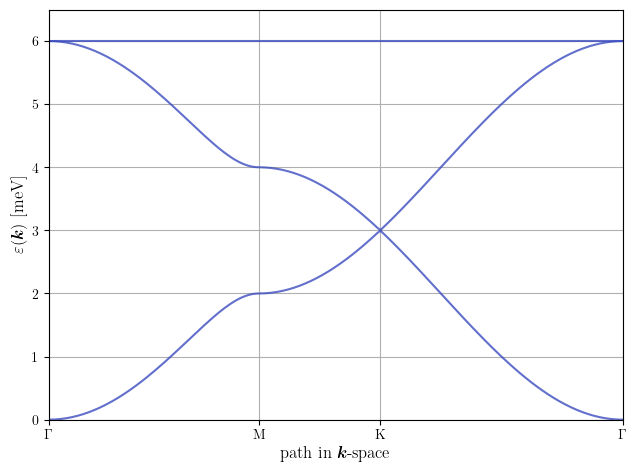

In [21]:
bz = Hexagonal(hamil, 'kagome')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
# bz.save_dispersion(disp, fname='test')
fig = bz.plot_dispersion(disp)
fig.gca().set_xlabel(r"path in $\bm{k}$-space", fontsize=12)
fig.gca().set_ylabel(r"$\varepsilon(\bm{k}) \, \, [\mathrm{meV}]$", fontsize=12)
plt.margins(x=0, y=0)
plt.ylim(0,6.5)
plt.show()

In [22]:
v1, v2 = lat.num_rcpr_vects[:2]
parallelogram_grid(v1, v2, 10)

array([[[ 0.        ,  0.34906585,  0.6981317 ,  1.04719755,
          1.3962634 ,  1.74532925,  2.0943951 ,  2.44346095,
          2.7925268 ,  3.14159265],
        [ 0.        ,  0.34906585,  0.6981317 ,  1.04719755,
          1.3962634 ,  1.74532925,  2.0943951 ,  2.44346095,
          2.7925268 ,  3.14159265],
        [ 0.        ,  0.34906585,  0.6981317 ,  1.04719755,
          1.3962634 ,  1.74532925,  2.0943951 ,  2.44346095,
          2.7925268 ,  3.14159265],
        [ 0.        ,  0.34906585,  0.6981317 ,  1.04719755,
          1.3962634 ,  1.74532925,  2.0943951 ,  2.44346095,
          2.7925268 ,  3.14159265],
        [ 0.        ,  0.34906585,  0.6981317 ,  1.04719755,
          1.3962634 ,  1.74532925,  2.0943951 ,  2.44346095,
          2.7925268 ,  3.14159265],
        [ 0.        ,  0.34906585,  0.6981317 ,  1.04719755,
          1.3962634 ,  1.74532925,  2.0943951 ,  2.44346095,
          2.7925268 ,  3.14159265],
        [ 0.        ,  0.34906585,  0.6981317 ,  1.0

In [23]:
area_quadrilateral(np.array((0,0,0)), np.array((2,0,0)), np.array((1.5,1,0)), np.array((0.5,1,0)))

np.float64(1.5)

In [24]:
Es, EVs = hamil.evgrid(10)

In [25]:
print(EVs)

[[[[ 8.09909101e-01+0.00000000e+00j -1.03508040e-01+0.00000000e+00j
     5.77350240e-01+0.00000000e+00j  0.00000000e+00-0.00000000e+00j
     0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j]
   [-3.15313958e-01+0.00000000e+00j  7.53155876e-01+0.00000000e+00j
     5.77350240e-01+0.00000000e+00j  0.00000000e+00-0.00000000e+00j
     0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j]
   [-4.94595143e-01+0.00000000e+00j -6.49647836e-01+0.00000000e+00j
     5.77350240e-01+0.00000000e+00j  0.00000000e+00-0.00000000e+00j
     0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j]
   [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
     0.00000000e+00+0.00000000e+00j  8.09909101e-01-0.00000000e+00j
    -1.03508040e-01-0.00000000e+00j  5.77350240e-01-0.00000000e+00j]
   [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
     0.00000000e+00+0.00000000e+00j -3.15313958e-01-0.00000000e+00j
     7.53155876e-01-0.00000000e+00j  5.77350

In [26]:
hamil.chern(EVs)

array([ 1.00000000e+00,  4.24073958e-16, -7.00895340e-17,  1.00000000e+00,
        4.24073958e-16, -1.00000000e+00])

In [27]:
chern_numbers = np.around(hamil.chern(EVs), 2)
print(chern_numbers[:len(chern_numbers) // 2])
print(np.sum(chern_numbers[:len(chern_numbers) // 2],0))

[ 1.  0. -0.]
1.0


In [28]:
slab = hamil.slab(1,20)

In [29]:
slab.holstein_primakoff(simplify=True) ;

In [30]:
slab.parameterize_hamil()

1e-08

In [31]:
dir = hamil.lat.num_rcpr_vects[0]
ks = np.linspace(0, 1, 301)
energies = np.empty((len(ks), 2*slab.lat.nsublats))
amps = np.empty((len(ks), slab.lat.nsublats, slab.lat.nsublats))

for i, j in enumerate(ks):
    k = j*dir # cut dir vector into len(ks)-1 pieces
    E, EV = slab.bog_trafo(k[0], k[1], k[2])
    amp = slab.num_per_sl(EV)
    energies[i] = E
    amps[i] = amp

C:\Users\Pascal\AppData\Local\Temp\ipykernel_8300\1954182032.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  bandplot = plt.scatter(ks, energies[:,n], marker = '.', c = 'blue', edgecolor='none', cmap = 'coolwarm', vmin = -1.0, vmax = 1.0, zorder = 2)


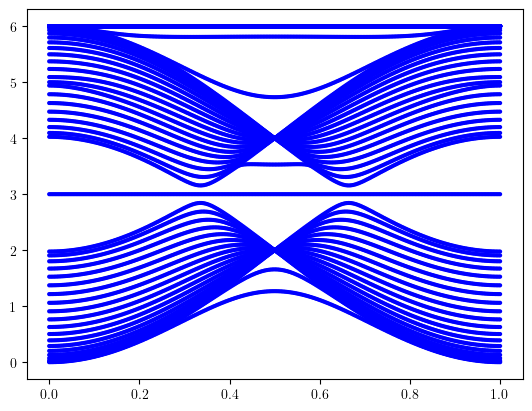

In [32]:
for n in range(0, slab.nbands):
    color = amps[:, n]
    bandplot = plt.scatter(ks, energies[:,n], marker = '.', c = 'blue', edgecolor='none', cmap = 'coolwarm', vmin = -1.0, vmax = 1.0, zorder = 2)

In [33]:
slab.lat.vects

Matrix([
[2*a,    0, 0],
[  0,    0, 1],
[  0, -2*a, 0]])